# Question 1

## Load Data

In [26]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' species
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()  # Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()

# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])

# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded']  # Target variable
X = df_filtered.drop(['species', 'island', 'sex', 'class_encoded'], axis=1)

       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]


## Train a logistic regression model

In [27]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model using the 'saga' solver
logreg = LogisticRegression(solver='saga')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Display the model coefficients and intercept
print("Coefficients:", logreg.coef_)
print("Intercept:", logreg.intercept_)

Accuracy: 0.5813953488372093
Coefficients: [[ 2.76067759e-03 -8.35214572e-05  4.53753284e-04 -2.86065695e-04]]
Intercept: [-8.57944894e-06]


C:\Users\Asus\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Classification accuracy using ``logreg = LogisticRegression(solver=’liblinear’)``

In [28]:
# do a classification using logreg = LogisticRegression(solver=’liblinear’) and find accuracy
# Initialize the logistic regression model with 'liblinear' solver
logreg = LogisticRegression(solver='liblinear')

# Train the model on the training data
logreg.fit(X_train, y_train)

# Predict the target variable for the test data
y_pred = logreg.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Display the model coefficients and intercept
print("Coefficients:", logreg.coef_)
print("Intercept:", logreg.intercept_)

Accuracy: 1.0
Coefficients: [[ 1.5997544  -1.43222015 -0.15123497 -0.00401141]]
Intercept: [-0.07601213]


## Compare the performance of the ``liblinear`` and ``saga`` solvers with feature scaling.

In [29]:
# Compare the performance of the ”liblinear” and ”saga” solvers with feature scaling
# using Standard Scaler available in sklearn library
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model using the 'liblinear' solver
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train_scaled, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (liblinear):", accuracy)

# Display the model coefficients and intercept
print("Coefficients:", logreg.coef_)
print("Intercept:", logreg.intercept_, "\n")

# Train the logistic regression model using the 'saga' solver
logreg = LogisticRegression(solver='saga')
logreg.fit(X_train_scaled, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (saga):", accuracy)

# Display the model coefficients and intercept
print("Coefficients:", logreg.coef_)
print("Intercept:", logreg.intercept_)

Accuracy (liblinear): 0.9767441860465116
Coefficients: [[ 3.77819685 -0.75341497  0.17248526 -0.71597049]]
Intercept: [-1.72205563] 

Accuracy (saga): 0.9767441860465116
Coefficients: [[ 3.90438942 -0.82348971  0.18543375 -0.73565028]]
Intercept: [-1.96725745]


# Plot features before and after scaling (Additional)

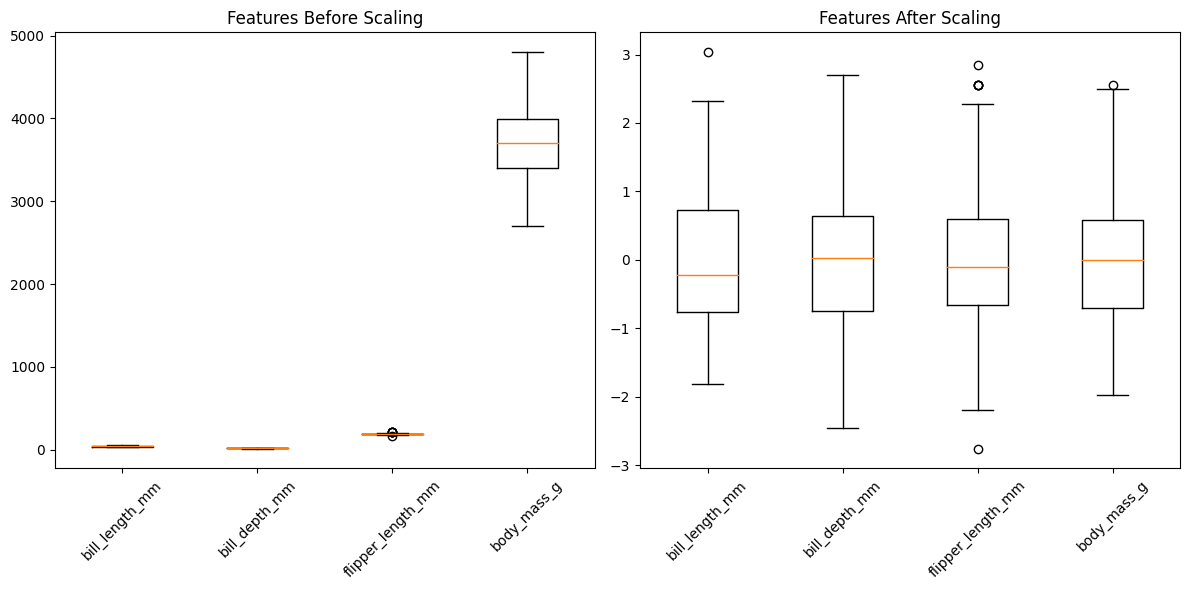

In [30]:
import matplotlib.pyplot as plt

# Plot the feature data before scaling
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Features Before Scaling")
plt.boxplot(X.values, labels=X.columns)
plt.xticks(rotation=45)

# Plot the feature data after scaling
plt.subplot(1, 2, 2)
plt.title("Features After Scaling")
plt.boxplot(X_train_scaled, labels=X.columns)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Correct the error by encoding

In [31]:
# encoding these categorical features and train the model
# BEGIN: Encode categorical features
# Ensure 'island' and 'sex' columns are included in X for encoding
X = df_filtered.drop(['species', 'class_encoded'], axis=1)

# Encode categorical features
X_encoded = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)

# Split the data into training and testing sets
X_train_encoded, X_test_encoded, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform the testing data
X_test_scaled = scaler.transform(X_test_encoded)

# Train the logistic regression model using the 'saga' solver
logreg = LogisticRegression(solver='saga')
logreg.fit(X_train_scaled, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy after one-hot encoding :", accuracy)
# END: Encode categorical features

Accuracy after one-hot encoding : 1.0


# Question 2

In [32]:
import pandas as pd

# Load the Excel file
file_path = r'C:\Users\Asus\Desktop\Sem 5\Pattern Recognition\Assignment 2\heart_failure_clinical_records_dataset.csv'  # Replace with the correct file path
data = pd.read_csv(file_path)

# Display general information about the dataset
print("Dataset Information:")
print(data.info())

# Display the first few rows of the dataset
print("\nFirst 5 Rows of the Dataset:")
print(data.head())

# Display summary statistics
print("\nSummary Statistics:")
print(data.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 

## correlation matrix

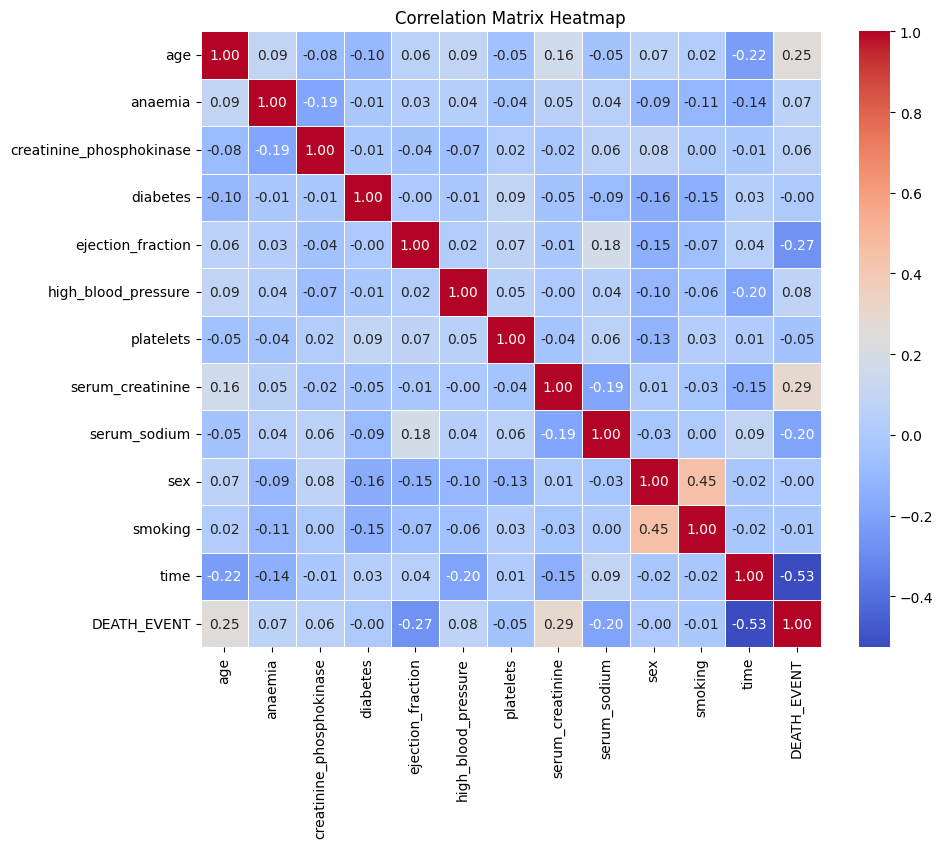

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate and print the correlation matrix
# Compute the correlation matrix for the selected columns
correlation_matrix = data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)

# Set the title
plt.title('Correlation Matrix Heatmap')

# Show the plot
plt.show()

## Select 5 features

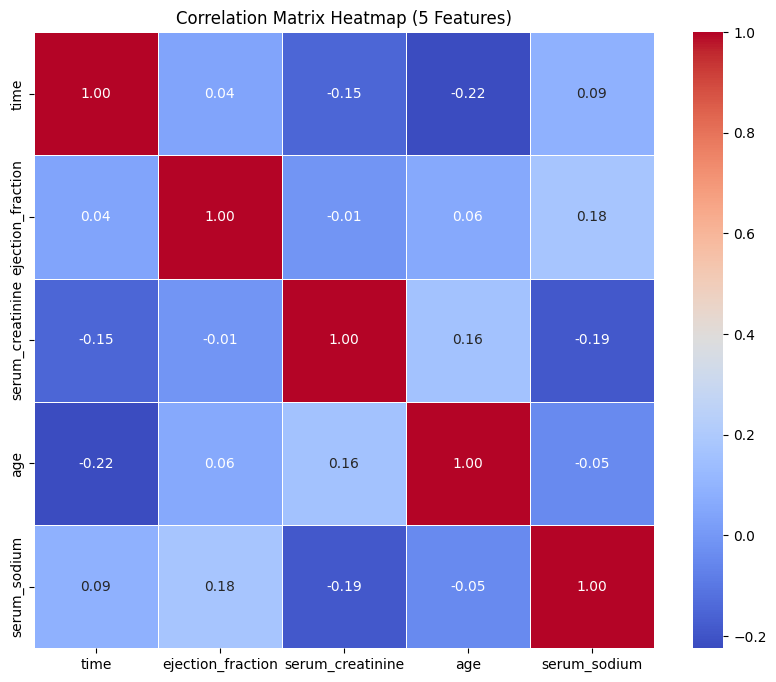

In [34]:
# Select the 5 features and include 'Heating Load' for the pair plot
# Correct column names based on the dataset
features = data[['time', 'ejection_fraction', 'serum_creatinine', 'age', 'serum_sodium']]

# Generate and print the correlation matrix
correlation_matrix = features.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)

# Set the title
plt.title('Correlation Matrix Heatmap (5 Features)')

# Show the plot
plt.show()

## obtain pair plots using sns.pairplot

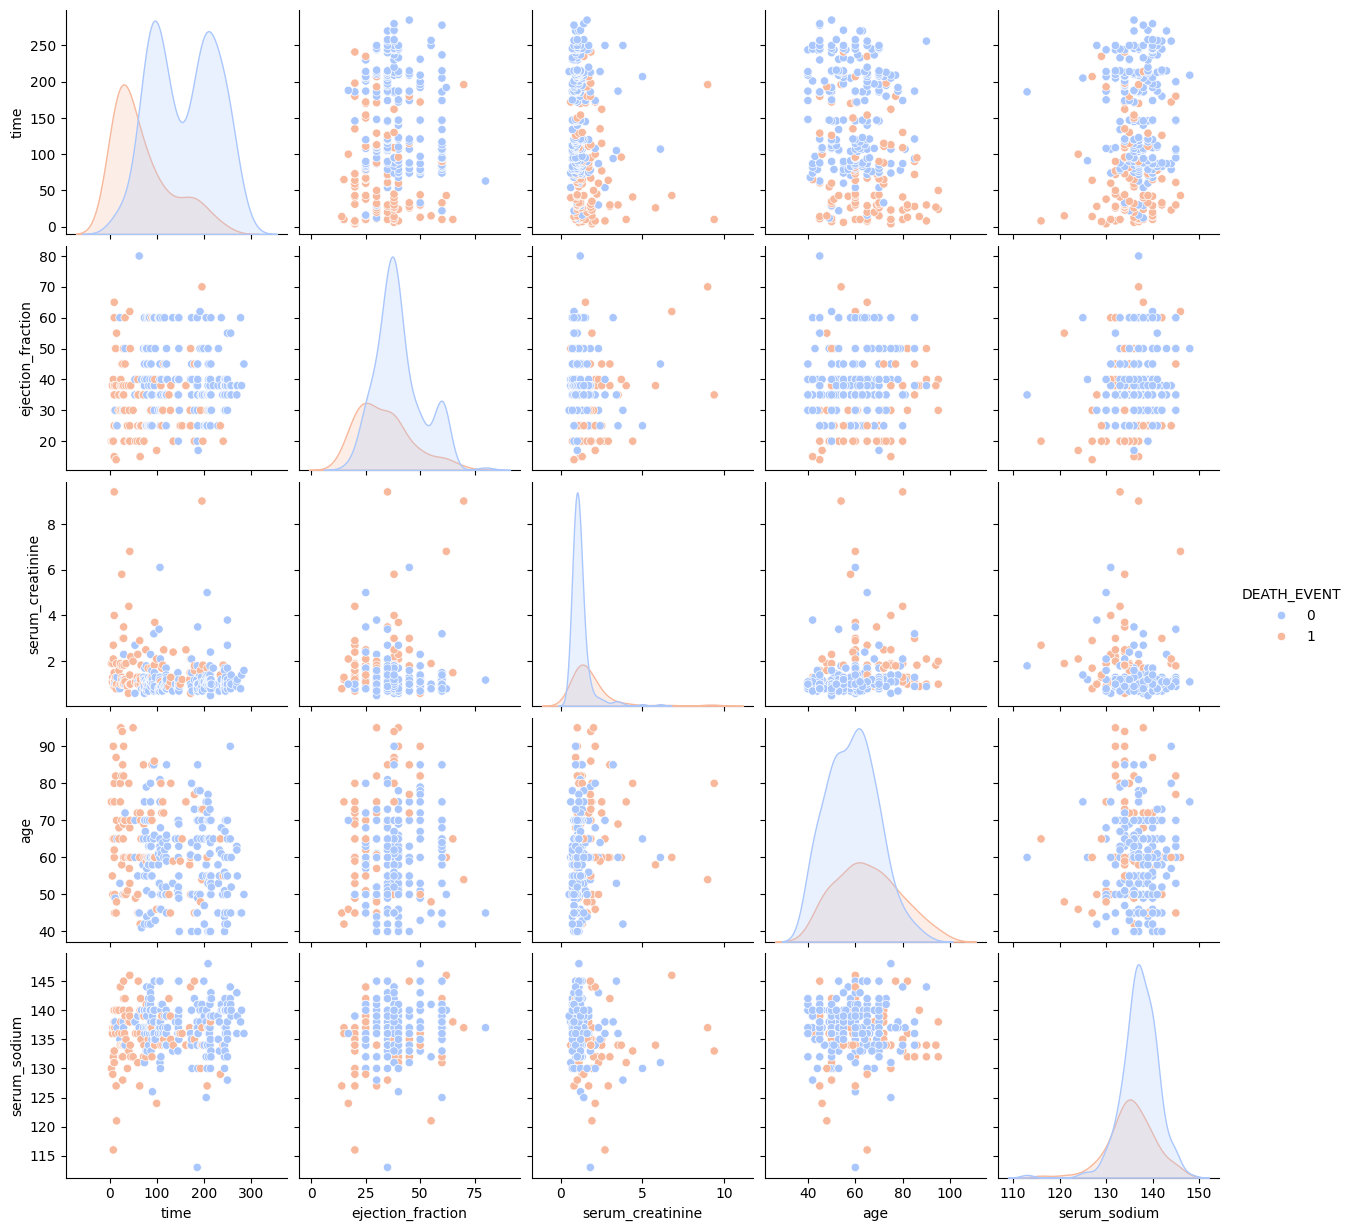

In [35]:
# Include 'DEATH_EVENT' in the features DataFrame
features = data[['time', 'ejection_fraction', 'serum_creatinine', 'age', 'serum_sodium', 'DEATH_EVENT']]

# Generate pair plots for the selected features
sns.pairplot(features, hue='DEATH_EVENT', palette='coolwarm')
plt.show()

##  Fit a logistic regression model

In [36]:
from sklearn.metrics import accuracy_score, classification_report

# Split the data into dependent and independent variables
X = data[['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'diabetes']]  # Independent variables
y = data['DEATH_EVENT']  # Dependent variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a logistic regression model
# Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = log_reg.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print accuracy and classification report
print(f"Accuracy of the model: {accuracy * 100:.2f}%")
print("Classification Report:")
print(report)

Accuracy of the model: 65.00%
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.91      0.75        35
           1       0.70      0.28      0.40        25

    accuracy                           0.65        60
   macro avg       0.67      0.60      0.58        60
weighted avg       0.67      0.65      0.61        60



## Use ``statsmodels.Logit`` to obtain and interpret the p-values for the predictors

In [37]:
# Use statsmodels.Logit to obtain and interpret the p-values for the predictors
import statsmodels.api as sm

# Fit the logistic regression model using statsmodels
logit_model = sm.Logit(y_train, sm.add_constant(X_train_scaled))
result = logit_model.fit()

# Print the summary of the model with feature names
result_summary = result.summary2()
result_summary.tables[1].index = ['const', 'age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'diabetes']
print(result_summary)

Optimization terminated successfully.
         Current function value: 0.471635
         Iterations 6
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: DEATH_EVENT      Pseudo R-squared: 0.225     
Date:               2024-10-02 23:15 AIC:              237.4413  
No. Observations:   239              BIC:              258.3001  
Df Model:           5                Log-Likelihood:   -112.72   
Df Residuals:       233              LL-Null:          -145.40   
Converged:          1.0000           LLR p-value:      9.4557e-13
No. Iterations:     6.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             -1.1569   0.1836 -6.3015 0.0000 -1.5168 -0.7971
age                0.7612   0.1780  4.2760 0.0000  0.4123  1.1101


# Question 3

# Logistic regression First/Second-Order Methods

## Generate data

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

In [39]:
# variable y and X are class labels and corresponding feature values, respectively
# display them
print("Class Labels (y):")
print(y[:10])
print("\nFeature Values (X):")
print(X[:10])

Class Labels (y):
[0 1 1 0 1 1 0 0 0 1]

Feature Values (X):
[[-2.19655439 -6.04817613]
 [ 0.81789766  4.8792503 ]
 [ 2.8314302   5.80299161]
 [-2.17405112 -6.11864355]
 [ 1.39572564  5.76178384]
 [ 2.96590984  5.85480084]
 [-2.2223128  -2.19679617]
 [-2.11888087 -1.70075188]
 [-3.42761651 -1.78349011]
 [ 2.60766743  4.34870788]]


##  Implement batch gradient descent for 20 iterations

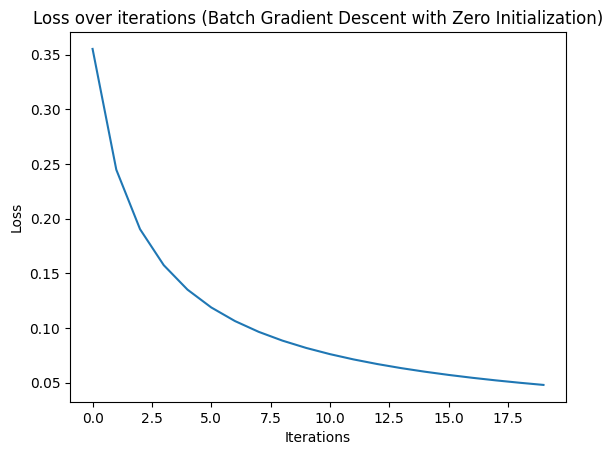

In [40]:
# Generate synthetic data
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(X, y, weights):
    m = X.shape[0]
    predictions = sigmoid(X.dot(weights))
    loss = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return loss

def batch_gradient_descent(X, y, weights, learning_rate, iterations):
    m = X.shape[0]
    losses = []
    for i in range(iterations):
        predictions = sigmoid(X.dot(weights))
        gradient = (1/m) * X.T.dot(predictions - y)
        weights -= learning_rate * gradient
        loss = compute_loss(X, y, weights)
        losses.append(loss)
    return weights, losses

# Initialize weights with zeros
weights = np.zeros(X.shape[1])  # Zero initialization

# Run batch gradient descent
weights, losses_bg = batch_gradient_descent(X, y, weights, learning_rate=0.1, iterations=20)

# Plot loss over iterations
plt.plot(losses_bg)
plt.title('Loss over iterations (Batch Gradient Descent with Zero Initialization)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

## Stochastic Gradient Descent

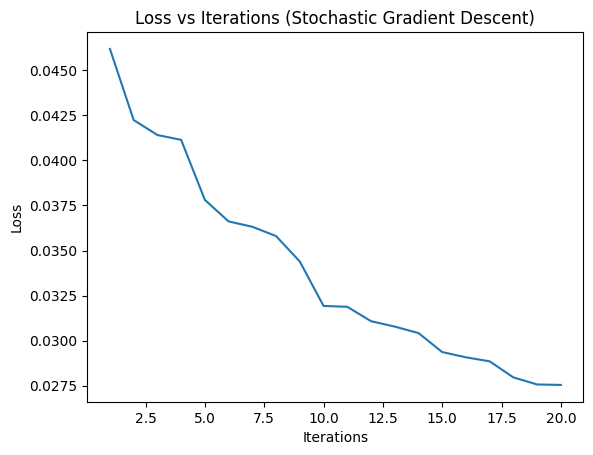

In [41]:
def stochastic_gradient_descent(X, y, weights, learning_rate, iterations):
    m = len(y)
    losses = []
    for i in range(iterations):
        # Randomly select an index for the current iteration
        rand_index = np.random.randint(0, m)
        
        # Select the corresponding feature vector and target value
        xi = X[rand_index].reshape(1, -1)  # Ensure xi is a row vector
        yi = y[rand_index].reshape(-1)  # Ensure yi is a scalar

        # Compute the prediction using the sigmoid function
        prediction = sigmoid(xi.dot(weights))  # Prediction is a scalar
        
        # Compute the gradient for the selected sample
        gradient = xi.T.dot(prediction - yi)  # Gradient shape matches weights

        # Update the weights using the computed gradient
        weights = weights - learning_rate * gradient  # Ensure weights update correctly

        # Compute the loss for the entire dataset after each iteration
        loss = compute_loss(X, y, weights)
        losses.append(loss)

    return weights, losses

# Run stochastic gradient descent
weights_sgd, losses_sgd = stochastic_gradient_descent(X, y, weights, learning_rate=0.1, iterations=20)

# Plot the loss over iterations
plt.plot(range(1, 21), losses_sgd, label="Stochastic Gradient Descent")
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations (Stochastic Gradient Descent)')
plt.show()

## Newton's Method

C:\Users\Asus\AppData\Local\Temp\ipykernel_59212\2069083546.py:14: RuntimeWarning: divide by zero encountered in log
  loss = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
C:\Users\Asus\AppData\Local\Temp\ipykernel_59212\2069083546.py:14: RuntimeWarning: invalid value encountered in multiply
  loss = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))


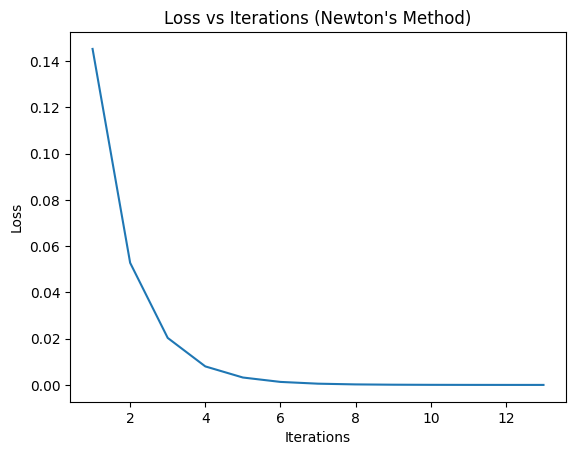

In [42]:
def newtons_method(features, labels, initial_weights, iterations):
    m = features.shape[0]
    losses = []
    weights = initial_weights
    for i in range(iterations):
        predictions = sigmoid(features.dot(weights))
        gradient = (1/m) * features.T.dot(predictions - labels)
        H = (1/m) * features.T.dot(np.diag(predictions * (1 - predictions))).dot(features)
        weights -= np.linalg.inv(H).dot(gradient)
        loss = compute_loss(features, labels, weights)
        losses.append(loss)
    return weights, losses

np.random.seed(0)
initial_weights = np.zeros(X.shape[1])
weights_newton, losses_newton = newtons_method(X, y, initial_weights, iterations=20)

plt.plot(range(1, 21), losses_newton, label="Newton's Method")
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations (Newton\'s Method)')
plt.show()

## Plot all in one

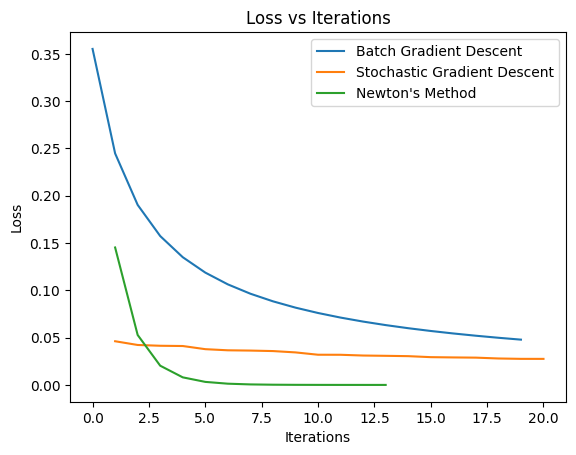

In [43]:
# plot aboove 3 plots in same graph
plt.plot(losses_bg, label="Batch Gradient Descent")
plt.plot(range(1, 21), losses_sgd, label="Stochastic Gradient Descent")
plt.plot(range(1, 21), losses_newton, label="Newton's Method")
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.legend()
plt.show()

## Convergence Analysis of Batch Gradient Descent with New Centers

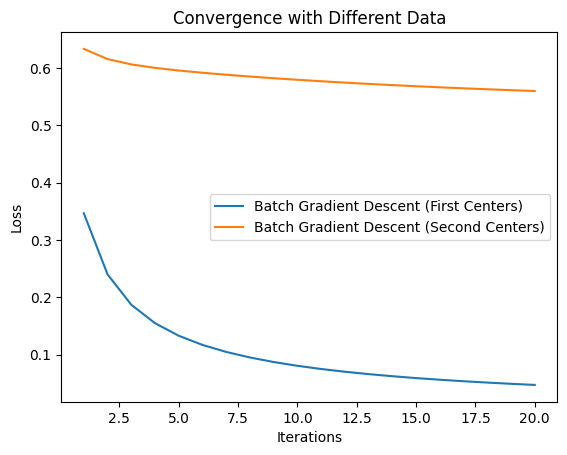

In [44]:
# Generate synthetic data for the first set of centers
np.random.seed(0)
centers_first = [[-5, 0], [5, 1.5]]
X_first, y_first = make_blobs(n_samples=2000, centers=centers_first, random_state=5)
transformation_first = [[0.5, 0.5], [-0.5, 1.5]]
X_first = np.dot(X_first, transformation_first)

# Generate synthetic data for the second set of centers
np.random.seed(0)
centers_second = [[3, 0], [5, 1.5]]
X_second, y_second = make_blobs(n_samples=2000, centers=centers_second, random_state=5)
transformation_second = [[0.5, 0.5], [-0.5, 1.5]]
X_second = np.dot(X_second, transformation_second)

# Initialize weights for the first dataset
weights_first = np.random.randn(X_first.shape[1]) * 0.01
weights_first, losses_first = batch_gradient_descent(X_first, y_first, weights_first, learning_rate=0.1, iterations=20)

# Initialize weights for the second dataset
weights_second = np.random.randn(X_second.shape[1]) * 0.01
weights_second, losses_second = batch_gradient_descent(X_second, y_second, weights_second, learning_rate=0.1, iterations=20)

# Plot the loss over iterations for both datasets
plt.plot(range(1, 21), losses_first, label="Batch Gradient Descent (First Centers)")
plt.plot(range(1, 21), losses_second, label="Batch Gradient Descent (Second Centers)")
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Convergence with Different Data')
plt.legend()
plt.show()